In [12]:
import numpy as np
from collections import defaultdict
from visualiser_plan import visualiser_batiment_3D

param_names = ['f_glazing_area', 'f_orientation', 'f_overall_height', 'f_relative_compactness', 'f_wall_area']
param_bounds = {
    'f_glazing_area': (10, 50),
    'f_orientation': (0, 3),
    'f_overall_height': (8, 20),
    'f_relative_compactness': (0.7, 1.0),
    'f_wall_area': (150, 300)
}
# Discrétisation pour Q-learning
param_steps = {
    'f_glazing_area': 2,
    'f_orientation': 1,
    'f_overall_height': 1,
    'f_relative_compactness': 0.05,
    'f_wall_area': 10
}

In [17]:
def reward_func(params):
    # Exemple fictif : on veut minimiser la consommation (ici, une formule arbitraire)
    # En pratique, utilisez votre modèle de prédiction ou une vraie simulation
    perf = (
        -0.5 * params['f_glazing_area']
        + 2 * (params['f_orientation'] == 2)  # Sud = mieux
        - 1.5 * abs(params['f_overall_height'] - 10)
        + 10 * params['f_relative_compactness']
        - 0.1 * params['f_wall_area']
    )
    return perf  # Plus c'est grand, mieux c'est

In [18]:
class QLearningAgent:
    def __init__(self, param_names, param_bounds, param_steps, alpha=0.1, gamma=0.9, epsilon=0.2):
        self.param_names = param_names
        self.param_bounds = param_bounds
        self.param_steps = param_steps
        self.actions = self._build_actions()
        self.q_table = defaultdict(float)
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

    def _build_actions(self):
        actions = []
        for name in self.param_names:
            step = self.param_steps[name]
            actions.append((name, step))
            actions.append((name, -step))
        return actions

    def discretize(self, params):
        d = []
        for n in self.param_names:
            step = self.param_steps[n]
            if n == 'f_orientation':
                d.append(int(round(params[n])))
            else:
                d.append(int(round((params[n] - self.param_bounds[n][0]) / step)))
        return tuple(d)

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return self.actions[np.random.randint(len(self.actions))]
        q_vals = [self.q_table[(state, a)] for a in self.actions]
        return self.actions[np.argmax(q_vals)]

    def update(self, state, action, reward, next_state):
        best_next = max([self.q_table[(next_state, a)] for a in self.actions])
        self.q_table[(state, action)] += self.alpha * (reward + self.gamma * best_next - self.q_table[(state, action)])

    def run_episode(self, initial_params, reward_func, n_steps=20):
        params = initial_params.copy()
        state = self.discretize(params)
        for _ in range(n_steps):
            action = self.choose_action(state)
            param, delta = action
            # Appliquer l'action
            if param == 'f_orientation':
                params[param] = int((params[param] + delta) % 4)
            else:
                params[param] = np.clip(params[param] + delta, *self.param_bounds[param])
            next_state = self.discretize(params)
            reward = reward_func(params)
            self.update(state, action, reward, next_state)
            state = next_state
        return params, reward_func(params)

In [22]:
agent = QLearningAgent(param_names, param_bounds, param_steps, alpha=0.2, gamma=0.95, epsilon=0.3)
best_params = None
best_score = -np.inf

for episode in range(100):
    # Initialisation aléatoire
    params = {n: np.random.uniform(*param_bounds[n]) if n != 'f_orientation' else int(np.random.randint(0, 4)) for n in param_names}
    final_params, score = agent.run_episode(params, reward_func, n_steps=30)
    if score > best_score:
        best_score = score
        best_params = final_params.copy()
    if episode % 10 == 0:
        print(f"Episode {episode}: score={score:.2f}")

print("\nMeilleure configuration trouvée:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"Score de performance énergétique: {best_score:.2f}")

Episode 0: score=-44.25
Episode 10: score=-48.74
Episode 20: score=-49.03
Episode 30: score=-41.82
Episode 40: score=-49.97
Episode 50: score=-48.98
Episode 60: score=-49.00
Episode 70: score=-35.60
Episode 80: score=-43.47
Episode 90: score=-42.54

Meilleure configuration trouvée:
  f_glazing_area: 34.715170445295726
  f_orientation: 2
  f_overall_height: 9.302159013859313
  f_relative_compactness: 0.98996972012564
  f_wall_area: 189.61740681081935
Score de performance énergétique: -25.47


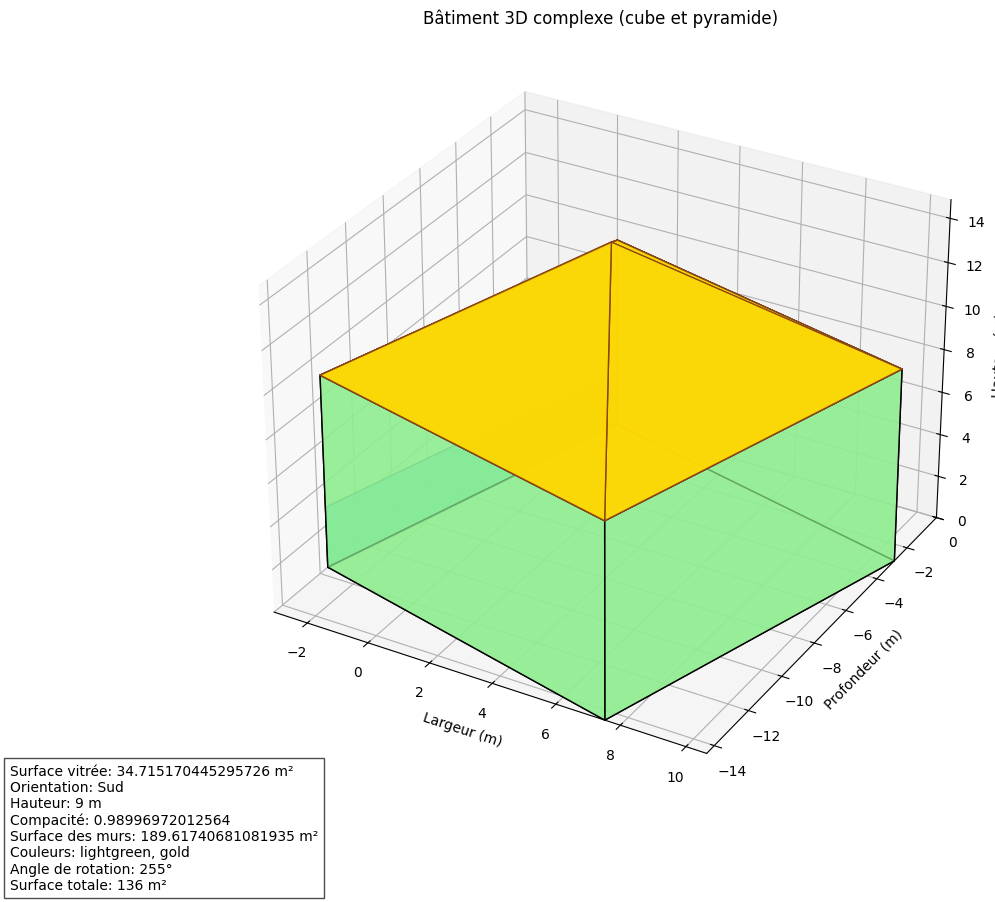

In [23]:
visualiser_batiment_3D(best_params)